# Natural Alpha Transfer

In [112]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
tqdm.pandas()

In [2]:
sig_path  = os.getcwd()
res_path  = os.path.abspath(os.path.join(sig_path, ".."))
repo_path = os.path.abspath(os.path.join(res_path, ".."))
data_path = os.path.join(repo_path, "data")

In [3]:
path     = os.path.join(data_path, "CFTC", "CFTCData.parquet")
df_ratio = (pd
    .read_parquet(path = path, engine = "pyarrow")
    [["date", "PX_LAST", "subgroup", "future"]]
    .groupby(["date", "subgroup", "future"])
    .agg("sum")
    .reset_index()
    .pivot(index = ["date", "future"], columns = "subgroup", values = "PX_LAST")
    .assign(cuml_val = lambda x: x.sum(axis = 1))
    .assign(ratio = lambda x: x["Money Managers"] / x.cuml_val)
    .reset_index()
    [["date", "future", "ratio"]]
    .dropna())

<Axes: xlabel='date'>

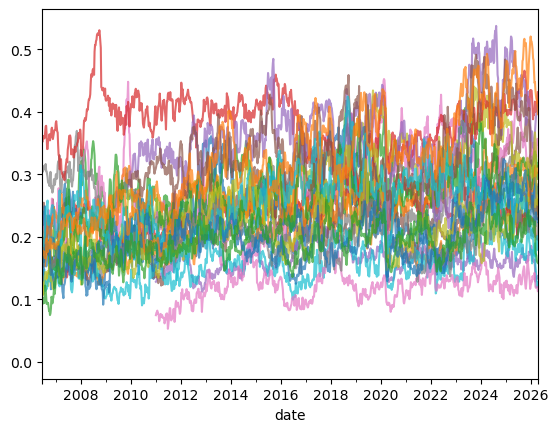

In [4]:
(df_ratio
    .pivot(index = "date", columns = "future", values = "ratio")
    .plot(legend = False, alpha = 0.7))

In [10]:
df_mean = (df_ratio
    .drop(columns = ["date"])
    .groupby("future")
    .agg("mean")
    .reset_index()
    .assign(ticker = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower()))

In [15]:
tickers = df_mean.ticker.drop_duplicates().sort_values().to_list()

In [63]:
def lo_autocorr_measure(df, n=100):

    returns     = df.R.dropna()
    sigma_daily = returns.std()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)

        rho = np.array([
            returns.autocorr(lag=i)
            for i in range(1, n)
        ])

    weights = (n - np.arange(1, n)) / n

    autocorr_term = (
        1
        + 2 * np.sum(weights * rho)
    )

    trendiness = np.sqrt(autocorr_term)

    sigma_annual = (
        np.sqrt(n)
        * sigma_daily
        * trendiness
    )

    return pd.Series({
        "sigma_daily": sigma_daily,
        "autocorr_term": autocorr_term,
        "trendiness": trendiness,
        "sigma_annual": sigma_annual
    })

ERROR! Session/line number was not unique in database. History logging moved to new session 7657


In [56]:
path      = r"C:\Users\Diego\Documents\GitHub\TrendSystem\data\Signals\DaoNguyenDerembleLemperiereBouchaudPotters.parquet"
df_signal = (pd
    .read_parquet(path = path, engine = "pyarrow")
    .set_index("date")
    .loc[lambda x: x.ticker.isin(tickers)])

In [57]:
df_trediness = (df_signal
    .groupby("ticker")
    .apply(lo_autocorr_measure))

<Axes: xlabel='ratio', ylabel='trendiness'>

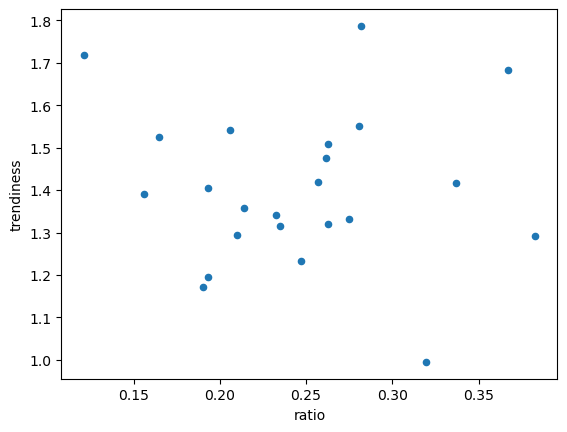

In [58]:
(df_trendiness
    [["trendiness"]]
    .merge(right = df_mean, how = "inner", on = ["ticker"])
    .plot(kind = "scatter", x = "ratio", y = "trendiness"))

In [66]:
df_yearly_trend = (df_signal
    .reset_index()
    .loc[lambda x: x.ticker.isin(tickers)]
    .assign(month_date = lambda x: pd.to_datetime(x.date).dt.year)
    [["month_date", "ticker", "R"]]
    .groupby(["month_date", "ticker"])
    .progress_apply(lambda group: lo_autocorr_measure(group))
    .dropna())

100%|████████████████████████████████████████████████████████████████████████████████| 570/570 [00:18<00:00, 31.22it/s]


In [82]:
df_yearly_ratio = (df_ratio
    .assign(year = lambda x: x.date.dt.year)
    [["year", "future","ratio"]]
    .groupby(["future", "year"])
    .agg("mean")
    .reset_index()
    .assign(ticker = lambda x: x.future.str.replace(" 1", "1").str.replace(" ", "_").str.lower()))

In [86]:
df_combined = (df_yearly_trend
    .reset_index()
    [["month_date", "ticker", "trendiness"]]
    .rename(columns = {"month_date": "year"})
    .merge(right = df_yearly_ratio, how = "inner", on = ["year", "ticker"]))

<Axes: xlabel='ratio', ylabel='trendiness'>

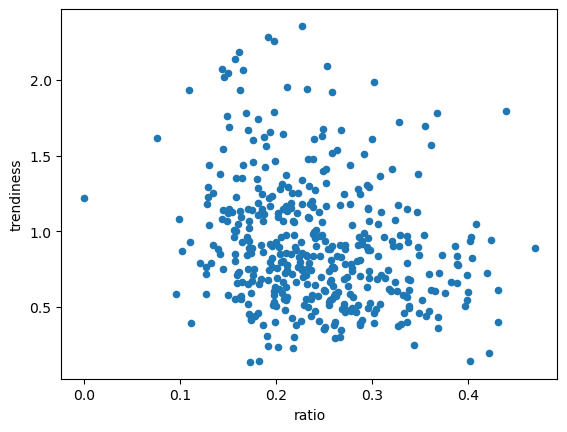

In [87]:
(df_combined
    .plot(kind = "scatter", x = "ratio", y = "trendiness"))

In [88]:
import statsmodels.api as sm

In [95]:
df_tmp = df_combined.assign(lag_ratio = lambda x: x.ratio.shift()).dropna()

In [98]:
model = (sm.OLS(endog = df_tmp.trendiness, exog = sm.add_constant(df_tmp.ratio)).fit())

In [99]:
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:             trendiness   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.048
Method:                 Least Squares   F-statistic:                     22.22
Date:                Fri, 07 Aug 2026   Prob (F-statistic):           3.31e-06
Time:                        15:00:16   Log-Likelihood:                -217.82
No. Observations:                 421   AIC:                             439.6
Df Residuals:                     419   BIC:                             447.7
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.2224      0.068     17.902      0.000       1.088       1.357
ratio         -1.2711      0.270     -4.714      0.000      -1.801      -0.741
==============================================================================
Omnibus:                       50.900   Durbin-Watson:                   1.670
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               66.816
Skew:                           0.893   Prob(JB):                     3.10e-15
Kurtosis:                       3.786   Cond. No.                         14.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [107]:
model = (sm.OLS(endog = df_tmp.trendiness, exog = sm.add_constant(df_tmp.ratio)).fit())
model_params = model.params.to_dict()

In [110]:
x = np.linspace(start = df_tmp.ratio.min(), stop = df_tmp.ratio.max(), num = 1_000)
y = (model_params["ratio"] * x) + model_params["const"]

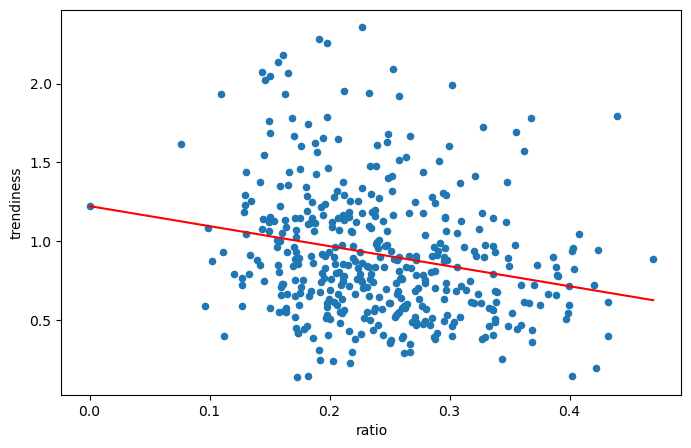

In [116]:
fig, axes = plt.subplots(figsize = (8,5))

(df_combined
    .plot(
        ax   = axes,
        kind = "scatter", x = "ratio", y = "trendiness"))

axes.plot(x,y, color = "red")